<a href="https://colab.research.google.com/github/Wanjala-B/Machine-Learning-Classification-/blob/main/Classification_in_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Handwritten Digit Classification Project

This repository documents a machine learning project focused on classifying handwritten digits using the MNIST dataset. The goal is to build and evaluate models capable of accurately identifying digits from images. This notebook serves as a step-by-step guide through data loading, exploration, preprocessing, model training, and evaluation.

In [8]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1)
mnist.keys()



dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [9]:
X, y = mnist["data"], mnist["target"]
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (70000, 784)
y shape: (70000,)


In [19]:
!pip install matplotlib

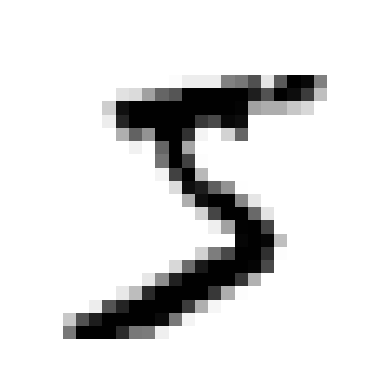

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

some_digit = X.iloc[0]
some_digit_image = some_digit.values.reshape(28,28)

plt.imshow(some_digit_image, cmap="binary")

plt.axis("off")
plt.show()

In [29]:
y[0]

'5'

## Data Loading and Initial Exploration

We begin by loading the MNIST dataset, which consists of 70,000 small images of handwritten digits. Each image is 28x28 pixels. The dataset is fetched using `sklearn.datasets.fetch_openml`.

The dataset provides pixel data (`data`) and corresponding labels (`target`). We've explored the dataset keys to understand its structure.

To get a visual understanding of the data, we've displayed the first digit from the dataset by reshaping its 784 pixel values (28x28) into a 2D array and using `matplotlib` to plot it. As observed, the first digit is a '5'.

In [13]:
y = y.astype(np.uint8)
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


After visualizing the first digit, we confirmed its label by inspecting `y[0]`, which showed '5'. This confirms that our visual representation matches the corresponding label.

Furthermore, we converted the `y` (target) Series to `np.uint8`. This is a common practice for classification tasks as it optimizes memory usage and ensures that the labels are represented as efficient integer types, suitable for machine learning models that expect numerical class labels.

In [14]:
X_train, X_test, y_train, y_test= X[:60000], X[60000:], y[:60000], y[60000:]

## Data Splitting: Training and Test Sets

To evaluate the performance of our machine learning models, it's essential to split the dataset into two main parts: a training set and a test set.

*   **Training Set (X_train, y_train):** This portion of the data (the first 60,000 instances) is used to train our models. The model learns patterns and relationships from these examples.
*   **Test Set (X_test, y_test):** This unseen portion of the data (the last 10,000 instances) is used to evaluate how well our trained model generalizes to new, previously unseen examples. This helps us assess the model's performance and avoid overfitting.

By keeping the test set separate during training, we can get an unbiased estimate of the model's true performance.

In [19]:

y_train_5 = (y_train == 5) # This creates a binary target for '5's
y_test_5 = (y_test == 5)   # This creates a binary target for '5's in the test set

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5) # Train the classifier to detect '5's using the binary target

# The prediction will now be True (is a 5) or False (is not a 5)
print(sgd_clf.predict(some_digit.to_frame().T))

[ True]


## Training a Binary Classifier for '5's

In this section, a've trained an `SGDClassifier` to act as a binary classifier, specifically designed to detect whether a given digit is a '5' or not.

*   **Target Preparation:** We created `y_train_5` and `y_test_5` by converting the original `y_train` and `y_test` labels into boolean arrays, where `True` indicates a '5' and `False` indicates any other digit. This is crucial for binary classification.
*   **Model Initialization and Training:** An `SGDClassifier` (Stochastic Gradient Descent Classifier) was initialized and then trained (`fit`) using `X_train` (the training image data) and `y_train_5` (our binary '5' target).
*   **Prediction:** We then used the trained classifier to predict on `some_digit` (which is known to be a '5'). The model correctly predicted `True`, indicating it recognized the digit as a '5'. I also ensured that the input to `predict` was a DataFrame to maintain feature name consistency.

In [22]:

y_train_7 = (y_train == 7)
y_test_7 = (y_test == 7)

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_7)


print(sgd_clf.predict(some_digit.to_frame().T))

[False]


## Training a Binary Classifier for '7's

This section mirrors the previous one, but with the goal of training a binary classifier to detect '7's.

*   **Target Preparation:** Similar to `y_train_5`, I created `y_train_7` and `y_test_7` to represent a binary target for the digit '7'.
*   **Model Initialization and Training:** Another `SGDClassifier` was initialized and trained on `X_train` with `y_train_7` as the target, making it a '7' vs. not-'7' classifier.
*   **Prediction:** When the classifier predicted on `some_digit` (which is a '5'), it correctly returned `False`, indicating that `some_digit` is not a '7'. This confirms the model's ability to differentiate the target digit.

## Resources

This project leverages several key resources and libraries for machine learning and data analysis:

*   **Scikit-learn:** A comprehensive Python library for machine learning, providing tools for classification, regression, clustering, and more. It is used here for data loading (`fetch_openml`), model selection (`SGDClassifier`, `cross_val_score`, `StratifiedKFold`), and general utility (`clone`).
*   **NumPy:** The fundamental package for numerical computation in Python, essential for handling arrays and mathematical operations.
*   **Pandas:** A powerful library for data manipulation and analysis, particularly useful for working with DataFrames and Series.
*   **Matplotlib:** A widely used plotting library for creating static, animated, and interactive visualizations in Python.
*   **MNIST Dataset:** A large database of handwritten digits that is commonly used for training various image processing systems. It was loaded using Scikit-learn's `fetch_openml` function.

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train.iloc[train_index]
    y_train_folds = y_train_5.iloc[train_index]
    X_test_fold = X_train.iloc[test_index]
    y_test_fold = y_train_5.iloc[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


In [25]:
# using cross val score fuction to evaluate the SGDClassifier model using k fold cross validation with three folds.

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

## Evaluating with `cross_val_score`

To simplify and standardize cross-validation, Scikit-Learn provides the `cross_val_score` function. This function performs K-fold cross-validation, training and evaluating the model `k` times, and returning an array of the evaluation scores.

In this cell:

*   We used `cross_val_score` with our `sgd_clf` (trained to detect '5's), the training data (`X_train`), and the binary target for '5's (`y_train_5`).
*   `cv=3` specifies 3-fold cross-validation, meaning the training set is split into 3 folds, and the model is trained on 2 folds and evaluated on the remaining fold, repeating this process three times.
*   `scoring="accuracy"` indicates that the performance metric we are interested in is accuracy.

The output `array([0.95035, 0.96035, 0.9604 ])` shows the accuracy for each of the three folds. These results are very similar to what we got with the manual `StratifiedKFold` implementation, confirming the model's high performance.

In [30]:
from typing import Never
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

## The `Never5Classifier` - A Baseline for Comparison

It's often useful to compare a classifier's performance against a very simple, non-learning baseline to understand if our model is actually learning anything meaningful. That's the purpose of the `Never5Classifier`:

*   **Custom Estimator:** We've defined a custom Scikit-Learn-compatible estimator called `Never5Classifier`. This classifier is intentionally simplistic.
*   **`fit` method:** The `fit` method does nothing, as this classifier doesn't actually learn from data.
*   **`predict` method:** The `predict` method *always* returns `False` for every input, meaning it *never* predicts that a digit is a '5'.

When we evaluate this `Never5Classifier` using `cross_val_score` on `X_train` and `y_train_5`:

*   The results `array([0.91125, 0.90855, 0.90915])` show an accuracy of around 91%. This might seem high for a classifier that does nothing!
*   The reason for this is that only about 9.1% of the MNIST dataset consists of '5's. If a classifier always predicts "not a 5", it will be correct approximately 90.9% of the time.

This demonstrates a crucial point: **accuracy alone can be misleading**, especially with imbalanced datasets. Our `SGDClassifier`'s accuracy of ~96% is significantly better than this baseline, indicating it genuinely learns to identify '5's.